# Práctica 6: Clasificación de datos

Se crea un modelo de K Vecinos Más Cercanos (KNN) para clasificar si una canción es de **rap** o de **pop** a partir de sus características de audio, y se evalúa con accuracy y matriz de confusión.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

PATH_INPUT = "../data/processed/spotify_cleaned.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Carga de datos

Ee deja una sola fila por canción (`uri`) y se usa `artist_genre` para crear la clase, los géneros que contienen rap, hip hop, trap o drill se toman como `rap`, los que contienen pop como `pop`, y el resto se descartan.

In [2]:
df = pd.read_csv(PATH_INPUT)
canciones = df.drop_duplicates("uri").copy()

genero = canciones["artist_genre"].astype(str)
es_rap = genero.str.contains("rap|hip hop|trap|drill")
es_pop = genero.str.contains("pop") & ~es_rap

canciones = canciones[es_rap | es_pop].copy()
canciones["clase"] = es_rap[es_rap | es_pop].map({True: "rap", False: "pop"})
print(canciones["clase"].value_counts())

clase
pop    900
rap    852
Name: count, dtype: int64


Las dos clases quedan casi del mismo tamaño, por lo que el accuracy es una métrica justa para este caso.

## Variables y división de datos

Como KNN calcula distancias, entonces se escalan las variables para que `tempo` o `loudness` no pesen más por tener valores más grandes. Se separa en 80% para entrenar y 20% para probar.

In [3]:
variables = ["danceability", "energy", "loudness", "speechiness", "acousticness", "valence", "tempo"]
X = canciones[variables]
y = canciones["clase"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# se ajusta el escalador solo con los datos de entrenamiento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Elección de k

In [4]:
ks = range(1, 31)
accs = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, knn.predict(X_test)))

mejor_k = ks[accs.index(max(accs))]
print(f"Mejor k = {mejor_k} con accuracy = {max(accs):.3f}")

Mejor k = 16 con accuracy = 0.806


## Modelo final y evaluación

In [5]:
modelo = KNeighborsClassifier(n_neighbors=mejor_k)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f"Accuracy = {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred))

Accuracy = 0.806

              precision    recall  f1-score   support

         pop       0.77      0.88      0.82       180
         rap       0.85      0.73      0.79       171

    accuracy                           0.81       351
   macro avg       0.81      0.80      0.80       351
weighted avg       0.81      0.81      0.81       351



## Gráficas

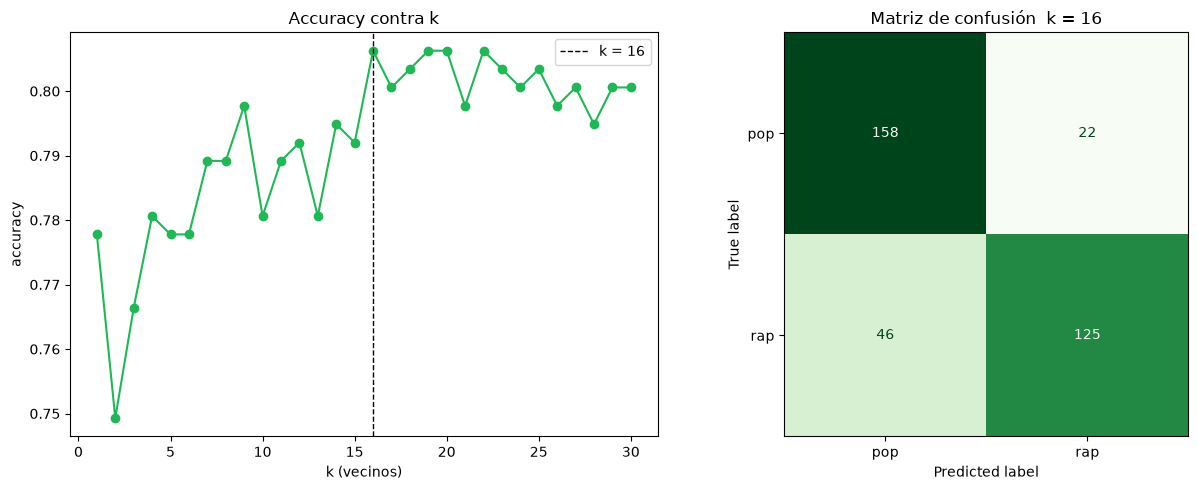

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# accuracy segun el valor de k
axes[0].plot(ks, accs, marker="o", color="#1DB954")
axes[0].axvline(mejor_k, color="black", ls="--", lw=1, label=f"k = {mejor_k}")
axes[0].set_xlabel("k (vecinos)")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy contra k")
axes[0].legend()

# matriz de confusion del modelo final
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Matriz de confusión  k = {mejor_k}")

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "knn_rap_pop.png"), dpi=150)
plt.show()

Con k = 16 el modelo clasifica correctamente el 80.6% de las canciones de prueba, lo cual es bastante bueno considerando que solo usa características de audio y que la etiqueta viene del género del artista, no de la canción.

En la gráfica de accuracy contra k se ve que con pocos vecinos (k = 1 a 6) el modelo es más inestable, y a partir de k ≈ 15 el accuracy se mantiene alrededor de 0.80, así que tomar más vecinos ayuda a minimizar el ruido.

Por otra parte, en la matriz de confusión el modelo reconoce mejor el pop (158 de 180, recall 0.88) que el rap (125 de 171, recall 0.73). El error más común es clasificar rap como pop (46 canciones), probablemente porque muchas canciones de rap o pop rap en el dataset tienen valores de `energy`, `loudness` y `valence` muy parecidos a los del pop, y la variable que más las separa es `speechiness`.